<a href="https://colab.research.google.com/github/OlaJTC/Assignment-10/blob/main/Ola_Mohammad_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 10: Customer Review Sentiment Analysis**

In [17]:
!git clone https://github.com/OlaJTC/Assignment-10

Cloning into 'Assignment-10'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [18]:
%cd Assignment-10

/content/Assignment-10


In [19]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


# **1. Dataset selection and loading**

In [20]:
#Setup & Data Loading
from datasets import load_dataset

imdb = load_dataset("stanfordnlp/imdb")
train_ds = imdb["train"]
test_ds = imdb["test"]


In [21]:
# Setup & Data Loading
!pip install -q datasets transformers scikit-learn gensim spacy matplotlib seaborn umap-learn

from datasets import load_dataset

train_ds = imdb["train"]
test_ds = imdb["test"]

train_texts = train_ds["text"]
train_labels = train_ds["label"]
test_texts = test_ds["text"]
test_labels = test_ds["label"]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 63.3 MB/s eta 0:00:00


# **2. Preprocessing**

**Basic text cleaning**

In [22]:
# Preprocessing
import re
import pandas as pd

def clean_text(t):
    t = t.lower()
    t = re.sub(r"<.*?>", " ", t)
    t = re.sub(r"[^a-z0-9']", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

train_df = pd.DataFrame({"text": train_texts, "label": train_labels})
test_df  = pd.DataFrame({"text": test_texts,  "label": test_labels})

train_df["text_clean"] = train_df["text"].apply(clean_text)
test_df["text_clean"]  = test_df["text"].apply(clean_text)


**Handling missing values**

In [23]:
# Drop rows with missing text or label (rare but safe)
train_df.dropna(subset=["text_clean", "label"], inplace=True)
test_df.dropna(subset=["text_clean", "label"], inplace=True)

**Feature scaling & one‑hot encoding**

For pure text models (BoW, TF‑IDF, BERT), we usually don’t need feature scaling or one‑hot encoding unless we add extra numeric/categorical features. we can mention in the report that scaling is not required for sparse text vectors, and categorical variables are not present in this dataset.


# **3. Feature engineering & vectorization**

**Bag of Words and TF‑IDF (scikit‑learn)**

In [24]:
# Vectorization (BoW & TF-IDF)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

max_features = 20000

bow_vectorizer = CountVectorizer(max_features=max_features, stop_words="english")
X_train_bow = bow_vectorizer.fit_transform(train_df["text_clean"])
X_test_bow  = bow_vectorizer.transform(test_df["text_clean"])

tfidf_vectorizer = TfidfVectorizer(max_features=max_features, stop_words="english")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["text_clean"])
X_test_tfidf  = tfidf_vectorizer.transform(test_df["text_clean"])

y_train = train_df["label"].values
y_test  = test_df["label"].values


**Word embeddings (Gensim Word2Vec)**

In [25]:
# Word Embeddings
from gensim.models import Word2Vec

tokenized_train = [t.split() for t in train_df["text_clean"]]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

word_vectors = w2v_model.wv

**Visualizing embeddings (PCA / t‑SNE)**

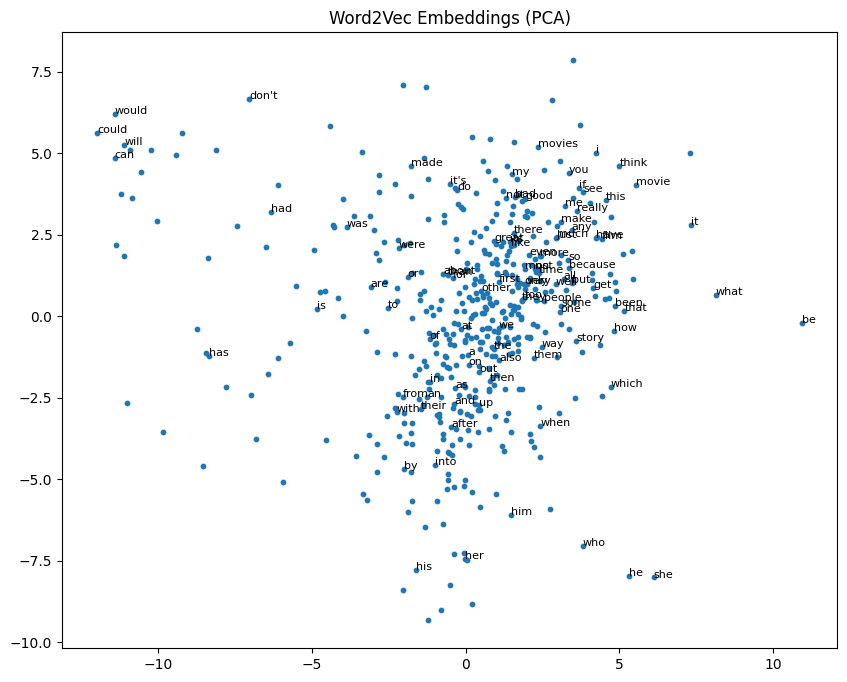

In [26]:
# Embedding Visualization
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

words = list(word_vectors.index_to_key[:500])
embs = np.array([word_vectors[w] for w in words])

pca = PCA(n_components=2)
embs_pca = pca.fit_transform(embs)

plt.figure(figsize=(10, 8))
plt.scatter(embs_pca[:, 0], embs_pca[:, 1], s=10)
for i, w in enumerate(words[:100]):  # annotate subset
    plt.annotate(w, (embs_pca[i, 0], embs_pca[i, 1]), fontsize=8)
plt.title("Word2Vec Embeddings (PCA)")
plt.show()


# **4. Text classification with traditional models**

**Logistic Regression & SVM**

In [27]:
# Traditional Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Example: Logistic Regression on TF-IDF
log_reg = LogisticRegression(max_iter=1000)

param_grid_lr = {
    "C": [0.1, 1.0, 10.0],
    "penalty": ["l2"]
}

grid_lr = GridSearchCV(
    log_reg,
    param_grid_lr,
    cv=3,
    scoring="f1",
    n_jobs=-1
)
grid_lr.fit(X_train_tfidf, y_train)

best_lr = grid_lr.best_estimator_

# Example: Linear SVM on TF-IDF
svm = LinearSVC()

param_grid_svm = {
    "C": [0.1, 1.0, 10.0]
}

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=3,
    scoring="f1",
    n_jobs=-1
)
grid_svm.fit(X_train_tfidf, y_train)

best_svm = grid_svm.best_estimator_


# **5. Sentiment analysis with BERT (Hugging Face)**

**Tokenization & dataset preparation**

In [28]:
# BERT Fine-tuning
from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments
import torch

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

imdb_tokenized = imdb.map(tokenize_batch, batched=True)

imdb_tokenized = imdb_tokenized.rename_column("label", "labels")
imdb_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

train_tokenized = imdb_tokenized["train"]
test_tokenized  = imdb_tokenized["test"]


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

**Model, training, and optimization**

In [29]:
import torch
from transformers import BertForSequenceClassification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
!pip install -U transformers

In [30]:
from transformers import TrainingArguments

In [31]:
import transformers
print(transformers.__version__)

5.16.1


# **6. Model evaluation & visualization**

**Metrics and confusion matrices**

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [33]:
# Run grid search
grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=3, scoring="f1", n_jobs=-1)
grid_lr.fit(X_train_tfidf, y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.1, 1.0, 10.0], 'penalty': ['l2']},
             scoring='f1')

Logistic Regression (TF-IDF) - Acc: 0.881, Prec: 0.879, Rec: 0.884, F1: 0.882


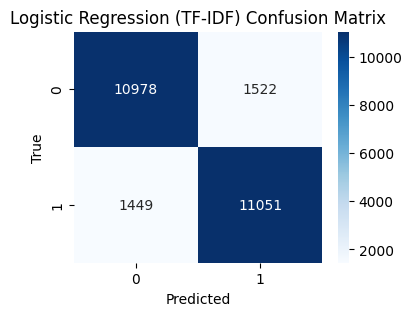

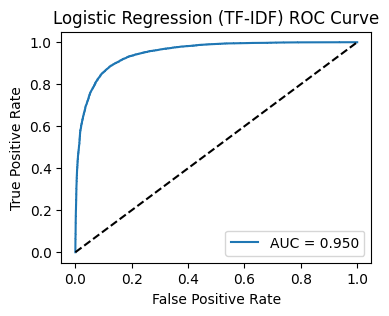

Linear SVM (TF-IDF) - Acc: 0.881, Prec: 0.877, Rec: 0.885, F1: 0.881


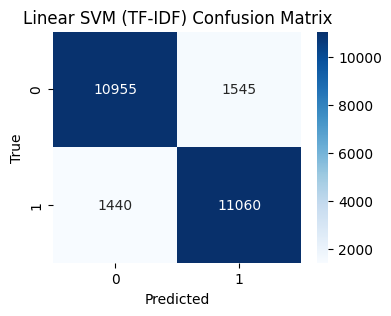

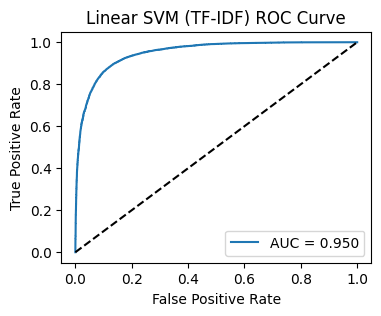

In [37]:
# Evaluation for Traditional Models
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # For models without predict_proba (e.g., LinearSVC), use decision_function
        if hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test)
        else:
            y_proba = None

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    print(f"{model_name} - Acc: {acc:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    if y_proba is not None:
        roc = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(4, 3))
        plt.plot(fpr, tpr, label=f"AUC = {roc:.3f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.title(f"{model_name} ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

evaluate_model(best_lr, X_test_tfidf, y_test, "Logistic Regression (TF-IDF)")
evaluate_model(best_svm, X_test_tfidf, y_test, "Linear SVM (TF-IDF)")
